YZ50 3.Hafta Task 1

In [46]:
words = open("names.txt", "r").read().splitlines()

In [47]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [48]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']                   # 'emma' -> ['.', 'e', 'm', 'm', 'a', '.']
    for ch1, ch2 in zip(chs, chs[1:]):              # (current, next) çiftleri
        print(ch1, ch2)

. e
e m
m m
m a
a .
. o
o l
l i
i v
v i
i a
a .
. a
a v
v a
a .


In [50]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1            # yoksa 0'dan başlat, 1 ekle


In [51]:
chars = sorted(list(set(''.join(words))))           # 26 harf: a..z
stoi = {s: i + 1 for i, s in enumerate(chars)}      # a=1, b=2, ..., z=26
stoi['.'] = 0                                       # "." -> 0 (tabloda ilk satır/sütun)
itos = {i: s for s, i in stoi.items()}
print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [52]:
import torch

N = torch.zeros((27, 27), dtype=torch.int32)        # sayım yapıyoruz -> int32 yeterli

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]                             # current karakterin index'i (satır)
        ix2 = stoi[ch2]                             # next karakterin index'i (sütun)
        N[ix1, ix2] += 1

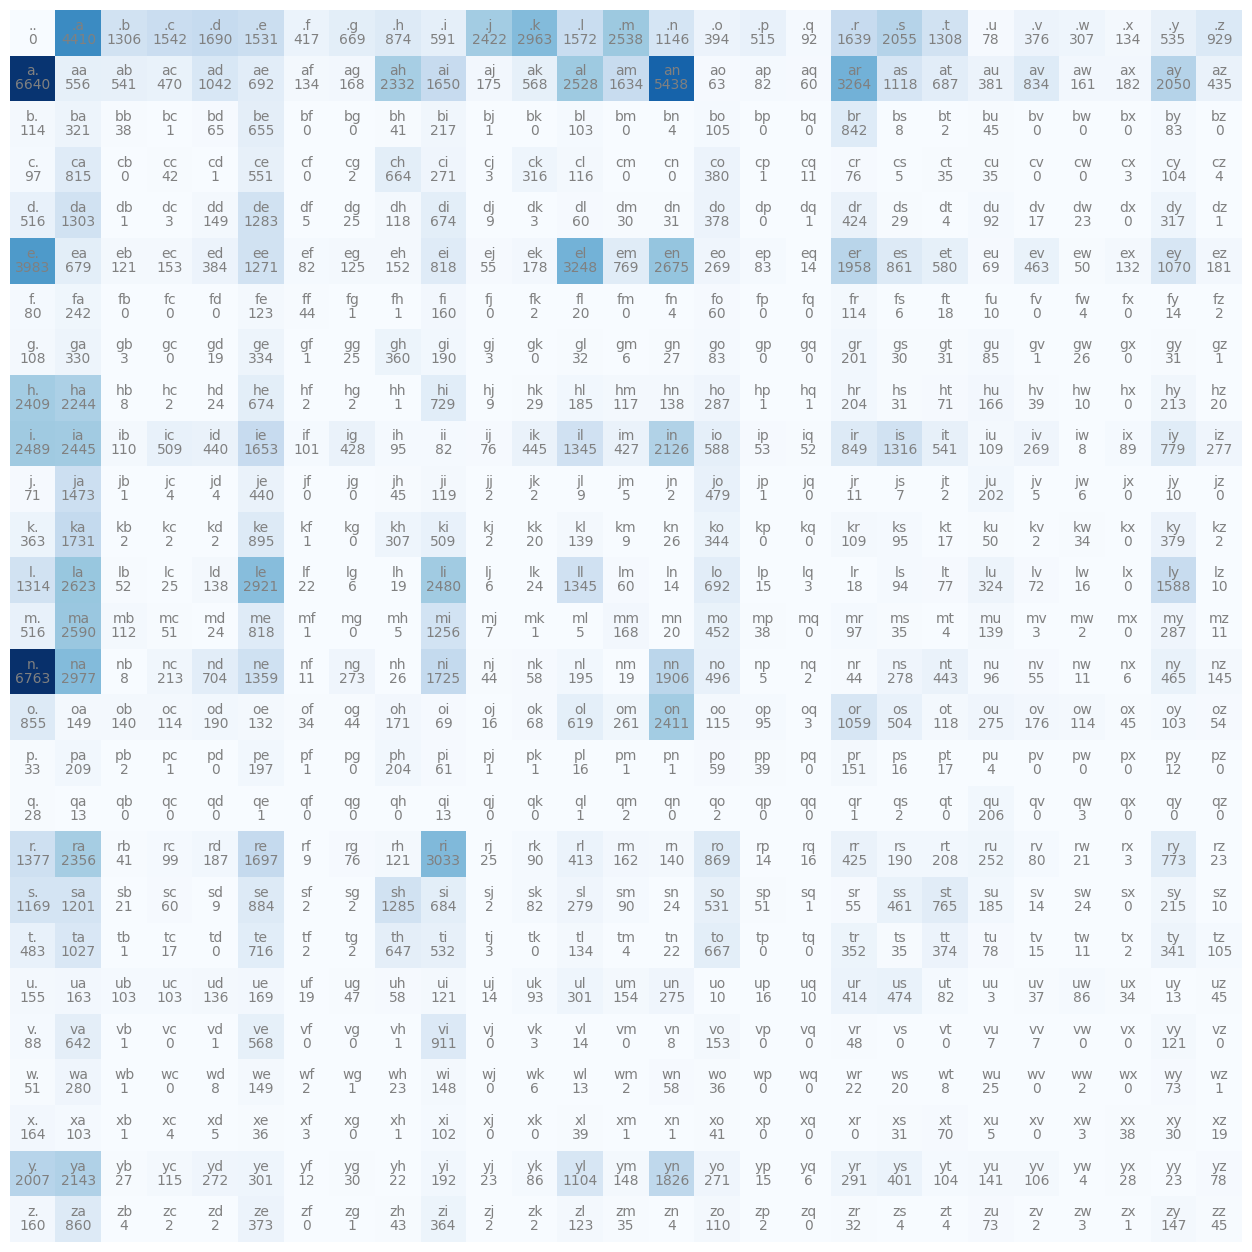

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]                   # hücrenin bigram'ı, örn. "an"
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')
plt.savefig('bigram_table.png', dpi=100, bbox_inches='tight')   # dosya istemiyorsan sil

Task 2

In [63]:
# 1) float'a çevir: bölme yapacağız, probability'ler decimal olacak
P = N.float()

# 2) her satırın toplamı = her current character için toplam next-character count
# 3) keepdim=True -> shape (27, 1). Böylece (27,27) / (27,1) broadcasting'i satır bazında çalışır.
#    keepdim=False olsa shape (27,) olur ve sessizce SÜTUNLARA bölerdik (videodaki bug).
row_sums = P.sum(1, keepdim=True)
print(row_sums.shape)                               # torch.Size([27, 1])

# 4) her hücreyi kendi satır toplamına böl -> P[current, next] = P(next | current)
P = P / row_sums
print(P.shape)                                      # torch.Size([27, 27])

torch.Size([27, 1])
torch.Size([27, 27])


In [65]:
print(P.sum(1))                                     # 27 tane 1.0000 görmelisin
print(torch.allclose(P.sum(1), torch.ones(27)))     # True

# 7a'daki örnek: "a" satırı = P(.|a), P(a|a), P(b|a), ..., P(z|a)
print(P[stoi['a']])
print(P[stoi['a']].sum().item())                    # 1.0

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
True
tensor([0.1960, 0.0164, 0.0160, 0.0139, 0.0308, 0.0204, 0.0040, 0.0050, 0.0688,
        0.0487, 0.0052, 0.0168, 0.0746, 0.0482, 0.1605, 0.0019, 0.0024, 0.0018,
        0.0963, 0.0330, 0.0203, 0.0112, 0.0246, 0.0048, 0.0054, 0.0605, 0.0128])
1.0


In [66]:
g = torch.Generator().manual_seed(2147483647)       # videodaki seed, aynı sonuçları almak için, argmax kullansaydık ne olurdu ?

# "." satırı = ilk harfin dağılımı. Buradan 20 kere sample et:
ix = torch.multinomial(P[0], num_samples=20, replacement=True, generator=g)
print([itos[i.item()] for i in ix])
# En yüksek olasılık 'a' (4410/32033 = 0.138) ama her seferinde 'a' gelmiyor.
# Sample, olasılığa göre zar atmak; argmax olsa hep 'a' seçerdi.

['m', 's', 'n', 'a', 'a', 't', 't', 'a', 'm', 'm', 'm', 'k', 'w', 'm', 's', 'r', 'z', 'k', 'g', 's']


In [68]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):                                  # 10) birkaç isim üret
    out = []
    current_index = stoi['.']                       # 6) başlangıç: "." -> 0

    while True:                                     # 7) döngü
        p = P[current_index]                        # a) current'ın probability satırı, shape (27,)
        next_index = torch.multinomial(              # b) dağılımdan sample et (argmax DEĞİL)
            p, num_samples=1, replacement=True, generator=g
        ).item()                                    # c) sample edilen index
        ch = itos[next_index]                       # d) index -> karakter

        if ch == '.':                               # 8) "." geldi -> isim bitti
            break
        out.append(ch)                              # e) isme ekle
        current_index = next_index                  # f) next artık current

    print(''.join(out))                             # 9) ismi göster

cexze
momasurailezitynn
konimittain
llayn
ka


Task 3

In [70]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]                          # P(next | current)
        logprob = torch.log(prob)                   # prob 0-1 arası -> log hep <= 0 (prob=1 -> 0)
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')  # .e: 0.0478 -3.0408 ...

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299


In [73]:
def nll_hesapla(P, words):
    log_likelihood = 0.0
    n = 0                                           # kaç bigram işlendi
    for w in words:                                 # dataset'teki bütün gerçek bigramlar
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            ix1 = stoi[ch1]                         # current index
            ix2 = stoi[ch2]                         # next index
            prob = P[ix1, ix2]                      # P(next | current)
            log_likelihood += torch.log(prob).item()  # log al, toplama ekle: log(a*b*c) = log a + log b + log c
            n += 1
    nll = -log_likelihood                           # negatifini al -> Negative Log Likelihood
    avg_nll = nll / n                               # bigram sayısına böl -> Average NLL
    return log_likelihood, nll, n, avg_nll

ll, nll, n, avg = nll_hesapla(P, words)
print(f'log_likelihood = {ll:.2f}')                 # -559891.75
print(f'nll            = {nll:.2f}')                #  559891.75
print(f'n              = {n}')                      #  228146
print(f'average nll    = {avg:.4f}')                #  2.4541  <- modelin "loss"u, düşük = iyi.  log(axb)--- log(a) + log(b)

log_likelihood = -559873.59
nll            = 559873.59
n              = 228146
average nll    = 2.4540


In [74]:
def carpim(P, words):
    likelihood = 1.0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            likelihood *= P[stoi[ch1], stoi[ch2]].item()   # olasılıkları direkt çarp
    return likelihood

print(carpim(P, words[:3]))                         # ~1e-17: 3 isimde bile çok küçük
print(carpim(P, words))                             # 0.0: 228146 çarpım -> underflow, bilgi yok oldu
# Aynı bilgiyi log toplamı (Hücre 14) -559891.75 olarak rahatça taşıyor.

1.4309086525157158e-17
0.0


In [76]:
P_smooth = (N + 1).float()                          # her hücreye +1 fake count -> 0 olasılık kalmaz
P_smooth = P_smooth / P_smooth.sum(1, keepdim=True) # keepdim! (Task 2)
# Fake count büyüdükçe dağılım uniform'a yaklaşır (her harf eşit olasılık); +1 hafif bir dokunuş.

ll_s, nll_s, n_s, avg_s = nll_hesapla(P_smooth, words)
print(f'smoothing öncesi average nll: {avg:.4f}')   # 2.4541
print(f'smoothing sonrası average nll: {avg_s:.4f}') # biraz daha yüksek: fake count gerçek dağılımı hafif bozar

smoothing öncesi average nll: 2.4540
smoothing sonrası average nll: 2.4546


Task 4

In [83]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])                        # input: current karakterin index'i
        ys.append(stoi[ch2])                        # target: next karakterin index'i

xs = torch.tensor(xs)                               # küçük t: dtype'ı veriden çıkarır -> int64 (one_hot bunu ister)
ys = torch.tensor(ys)                               # torch.Tensor (büyük T) float32 verirdi, o değil
num = xs.nelement()
print(num)                                          # 228146 = Task 3'teki n
print(xs[:5], ys[:5])                               # emma: [0, 5, 13, 13, 1] -> [5, 13, 13, 1, 0]

228146
tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


torch.Size([228146, 27])
tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])


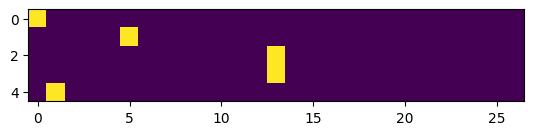

In [84]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()        # one_hot int64 döner; W float olacak, çarpım için .float() şart
print(xenc.shape)                                   # torch.Size([228146, 27])
print(xenc[1])                                      # 'e' (index 5): sadece 5. eleman 1
plt.imshow(xenc[:5])                                # emma'nın 5 one-hot satırı, videodaki görsel

In [85]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)   # 27 input feature -> 27 output; grad takibi açık
print(W.shape)

torch.Size([27, 27])


In [86]:
logits = xenc @ W                                   # 4.1 (228146, 27): her example için 27 raw score
counts = logits.exp()                               # 4.2 exp -> hepsi pozitif. Karpathy: logits = "log-count", exp = Task 1'deki N'in karşılığı
probs = counts / counts.sum(1, keepdim=True)        #     satır normalize (keepdim!) = softmax = Task 2'deki P'nin karşılığı
print(probs.shape, probs[0].sum().item())           # (228146, 27), 1.0

# Video not 1 (1:47:49): one-hot @ W aslında W'nin bir satırını seçmek
print(torch.allclose(logits[0], W[xs[0]]))          # True

print(probs[torch.arange(5), ys[:5]])               # 4.3 emma'nın 5 example'ında doğru target'ın olasılığı
loss = -probs[torch.arange(num), ys].log().mean()   # 4.4 average NLL: Task 3'teki hesap, P yerine softmax(W)
print(loss.item())                                  # ~3.77: eğitilmemiş W. Uniform tahmin bile log(27) = 3.30 verirdi

torch.Size([228146, 27]) 1.0000001192092896
True
tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150], grad_fn=<IndexBackward0>)
3.758953809738159


In [87]:
for k in range(300):
    # forward pass
    logits = xenc @ W                               # 4.1
    counts = logits.exp()                           # 4.2
    probs = counts / counts.sum(1, keepdim=True)    #     softmax
    nll = -probs[torch.arange(num), ys].log().mean()      # 4.3 + 4.4
    loss = nll + 0.01 * (W**2).mean()               # 4.5 regularization: W'yi 0'a çeker = smoothing'in NN karşılığı

    # backward pass
    W.grad = None                                   # 4.6 eski gradient'i temizle, birikmesin
    loss.backward()                                 # 4.7 micrograd'daki backward() ile aynı iş, tensor düzeyinde -> W.grad

    # gradient descent
    W.data += -50 * W.grad                          # 4.8 lr=50 videodan (0.1 çok yavaş kalıyordu); .data: güncelleme autograd'a kaydedilmesin

    if k % 30 == 0:
        print(k, loss.item(), nll.item())           # 4.9 ~3.77'den başlar, 2.4x'e iner

0 3.7686190605163574 3.758953809738159
30 2.5413522720336914 2.5306787490844727
60 2.5027060508728027 2.4895401000976562
90 2.4918932914733887 2.4771125316619873
120 2.4872729778289795 2.471369743347168
150 2.484917163848877 2.468189001083374
180 2.483569383621216 2.466215133666992
210 2.4827287197113037 2.4648890495300293
240 2.4821696281433105 2.46394681930542
270 2.4817800521850586 2.4632511138916016


In [88]:
print(f'Task 3, count model  avg NLL: {avg:.4f}')          # 2.4541
print(f'Task 4, neural net   avg NLL: {nll.item():.4f}')   # biraz üstünde; iterasyon artınca ve regularization azalınca 2.4541'e yaklaşır

# İki model aynı tabloyu mu öğrenmiş? softmax(W) = NN'in 27x27 olasılık tablosu
W_probs = W.detach().exp()
W_probs = W_probs / W_probs.sum(1, keepdim=True)
print(P[stoi['a']][:6])                             # Task 2: P(.|a), P(a|a), ...
print(W_probs[stoi['a']][:6])                       # neredeyse aynı sayılar
print((W_probs - P).abs().max().item())             # en büyük fark az veri olan satırlarda (q gibi): regularization orada daha çok çeker

Task 3, count model  avg NLL: 2.4540
Task 4, neural net   avg NLL: 2.4627
tensor([0.1960, 0.0164, 0.0160, 0.0139, 0.0308, 0.0204])
tensor([0.1955, 0.0164, 0.0160, 0.0139, 0.0307, 0.0204])
0.09878236055374146


Task 5

In [89]:
import pandas as pd

# CSV'yi Colab'a sol panelden yükle. Runtime sıfırlanınca silinir; kalıcı istersen Drive'a koyup mount et.
df = pd.read_csv('turkce_isim_clean.csv')           # dosya BOM'lu + CRLF: pandas ikisini de halleder
words = df['name'].tolist()
print(len(words))                                   # 13865
print(words[:8])                                    # ['aba', 'abaca', 'abacan', 'abaç', 'abay', 'abayhan', 'abaza', 'abbas']
print(min(len(w) for w in words), max(len(w) for w in words))   # 2 14

13865
['aba', 'abaca', 'abacan', 'abaç', 'abay', 'abayhan', 'abaza', 'abbas']
2 14


In [91]:
turkce_alfabe = 'abcçdefgğhıijklmnoöprsştuüvyz'     # 29 harf, Türkçe sıra

chars = sorted(set(''.join(words)), key=turkce_alfabe.index)   # dataset'teki unique karakterler, Türkçe sırayla
# düz sorted() code point'e göre sıralar, ç ö ü ğ ı ş en sona giderdi. Alfabe dışı bir karakter olsaydı
# .index ValueError verirdi; bu aslında iyi bir kontrol.
print(len(chars), ''.join(chars))                   # 29 abcçdefgğhıijklmnoöprsştuüvyz

stoi = {s: i + 1 for i, s in enumerate(chars)}      # a=1, b=2, c=3, ç=4, ...
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)
print(vocab_size)                                   # 30 (27 yerine)
print({c: stoi[c] for c in 'çğıöşü'})               # {'ç': 4, 'ğ': 9, 'ı': 11, 'ö': 19, 'ş': 23, 'ü': 26}

29 abcçdefgğhıijklmnoöprsştuüvyz
30
{'ç': 4, 'ğ': 9, 'ı': 11, 'ö': 19, 'ş': 23, 'ü': 26}


In [93]:
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)   # 30x30

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

print(N.sum().item())                               # 99873 bigram (İngilizce'de 228146 idi)
print((N == 0).sum().item(), 'sıfır hücre /', vocab_size**2)   # 160 / 900: hiç görülmemiş bigram, smoothing'in sebebi

99873
160 sıfır hücre / 900


(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

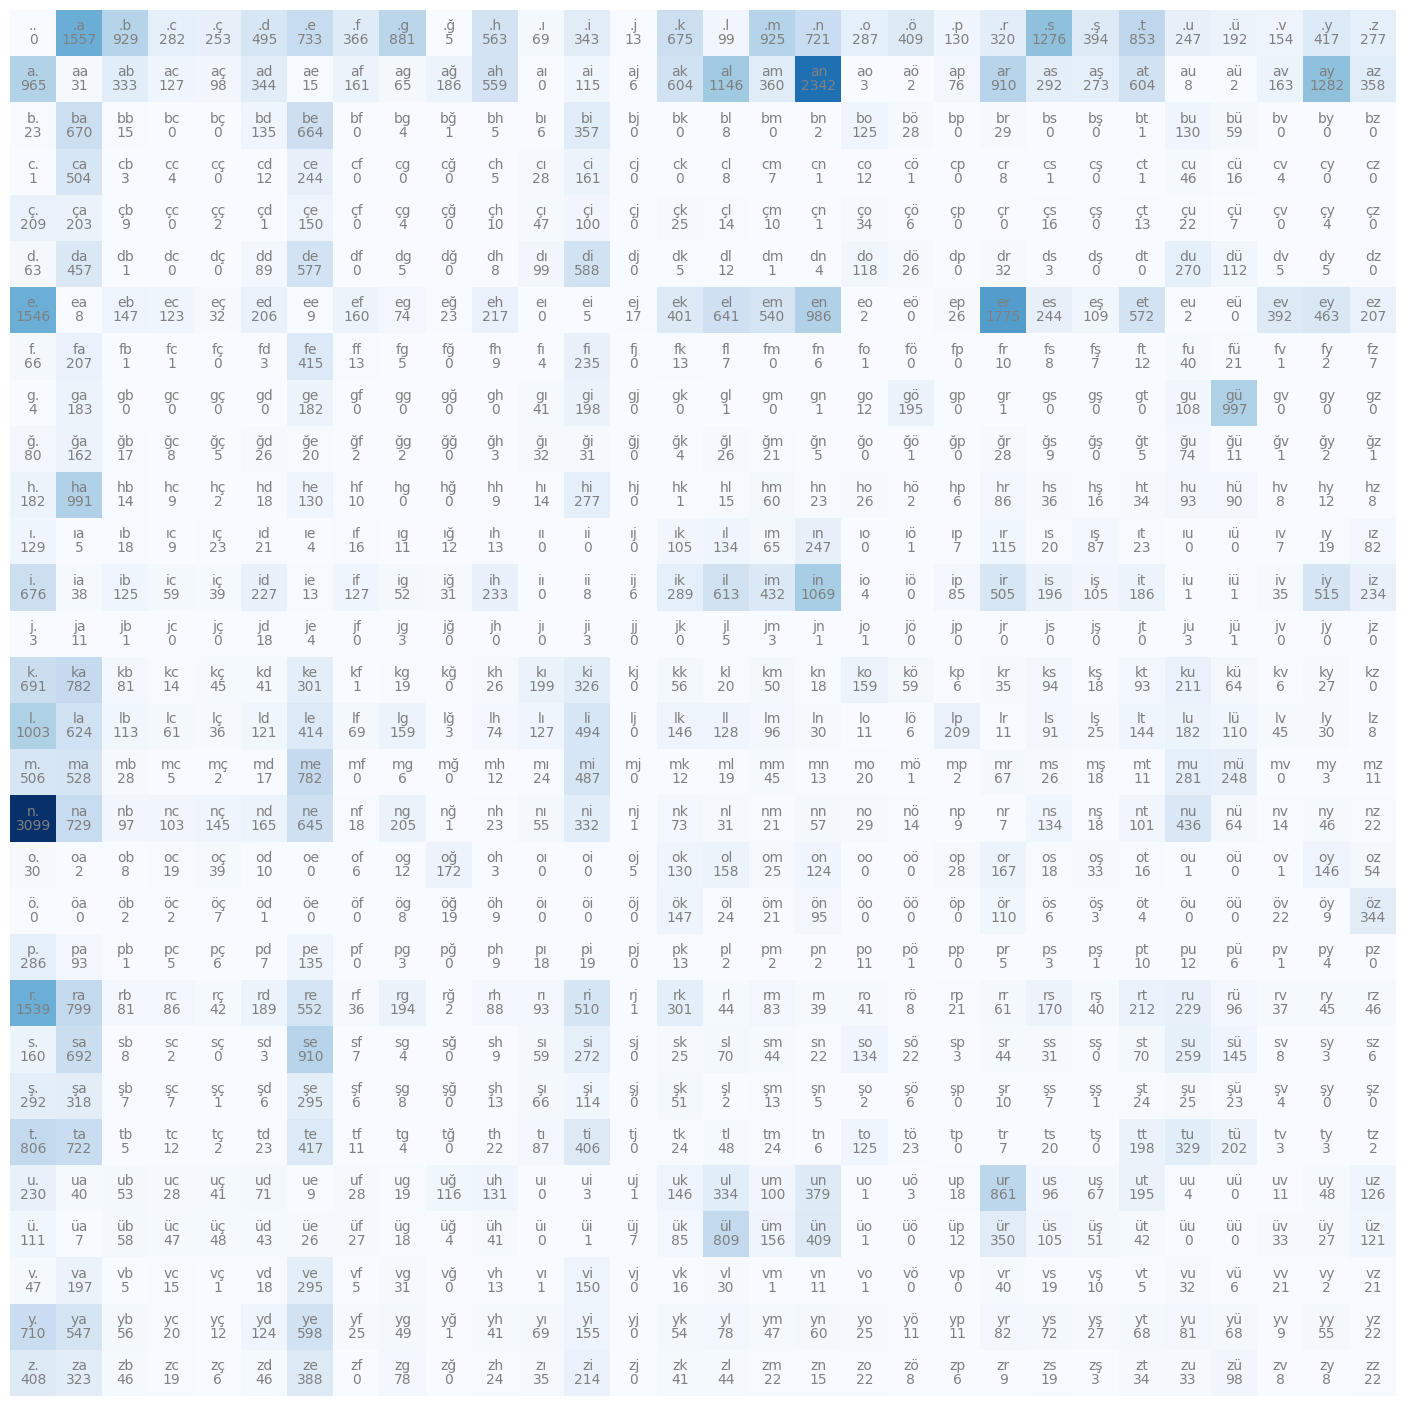

In [94]:
plt.figure(figsize=(18, 18))
plt.imshow(N, cmap='Blues')
for i in range(vocab_size):
    for j in range(vocab_size):
        plt.text(j, i, itos[i] + itos[j], ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')

In [95]:
P = (N + 1).float()                                 # +1 fake count (Task 3): 160 sıfır hücreye 0 olasılık kalmasın
P = P / P.sum(1, keepdim=True)                      # keepdim! (Task 2)
print(P.shape, torch.allclose(P.sum(1), torch.ones(vocab_size)))   # torch.Size([30, 30]) True

torch.Size([30, 30]) True


In [96]:
def avg_nll(P, words, stoi):
    log_likelihood = 0.0
    n = 0
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2 in zip(chs, chs[1:]):
            log_likelihood += torch.log(P[stoi[ch1], stoi[ch2]]).item()
            n += 1
    return -log_likelihood / n, n

avg_count, n = avg_nll(P, words, stoi)
print(n)                                            # 99873
print(f'count model avg NLL (Türkçe): {avg_count:.4f}')   # ~2.499 (İngilizce: 2.454)

99873
count model avg NLL (Türkçe): 2.4991


In [97]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0                                          # "."
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

caş
ayt
özoğbe
me
tan
hsoğip
n
bamiyışa
güğun
raşğsebunaceguğl


In [99]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(num)                                          # 99873 = Hücre 30'daki n

99873


In [100]:
xenc = F.one_hot(xs, num_classes=vocab_size).float()          # (99873, 30)
print(xenc.shape)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)   # 30x30

torch.Size([99873, 30])


In [101]:
for k in range(500):
    # A. forward
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)    # softmax
    # B + C. doğru target'ın olasılığı -> average NLL (+ regularization = smoothing'in NN karşılığı)
    nll = -probs[torch.arange(num), ys].log().mean()
    loss = nll + 0.01 * (W**2).mean()
    # D. backward
    W.grad = None
    loss.backward()
    # E. gradient descent
    W.data += -50 * W.grad
    # F. takip
    if k % 50 == 0:
        print(k, f'loss {loss.item():.4f}  nll {nll.item():.4f}')   # ~3.8'den başlar, 2.50 civarına iner

0 loss 3.9602  nll 3.9504
50 loss 2.5592  nll 2.5464
100 loss 2.5361  nll 2.5207
150 loss 2.5304  nll 2.5135
200 loss 2.5280  nll 2.5102
250 loss 2.5268  nll 2.5084
300 loss 2.5261  nll 2.5072
350 loss 2.5256  nll 2.5064
400 loss 2.5253  nll 2.5059
450 loss 2.5251  nll 2.5055


In [102]:
print(f'count model (smoothing +1) avg NLL: {avg_count:.4f}')   # ~2.499
print(f'neural net  (reg 0.01)     avg NLL: {nll.item():.4f}')   # ~2.50, yaklaşıyor

W_probs = W.detach().exp()
W_probs = W_probs / W_probs.sum(1, keepdim=True)    # softmax(W) = NN'in 30x30 tablosu
print((W_probs - P).abs().max().item())             # küçük: iki model aynı tabloyu öğrenmiş

count model (smoothing +1) avg NLL: 2.4991
neural net  (reg 0.01)     avg NLL: 2.5052
0.03583669662475586


In [103]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        xenc1 = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()
        logits1 = xenc1 @ W
        p = logits1.exp()
        p = p / p.sum(1, keepdim=True)              # softmax
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

caş
ayt
özoğbe
me
tan
hagöz
n
şat
iyışa
güğun
